DATASET INFORMATION
Dataset Shape: (2240, 29)

Column Names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

First 5 Rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_C

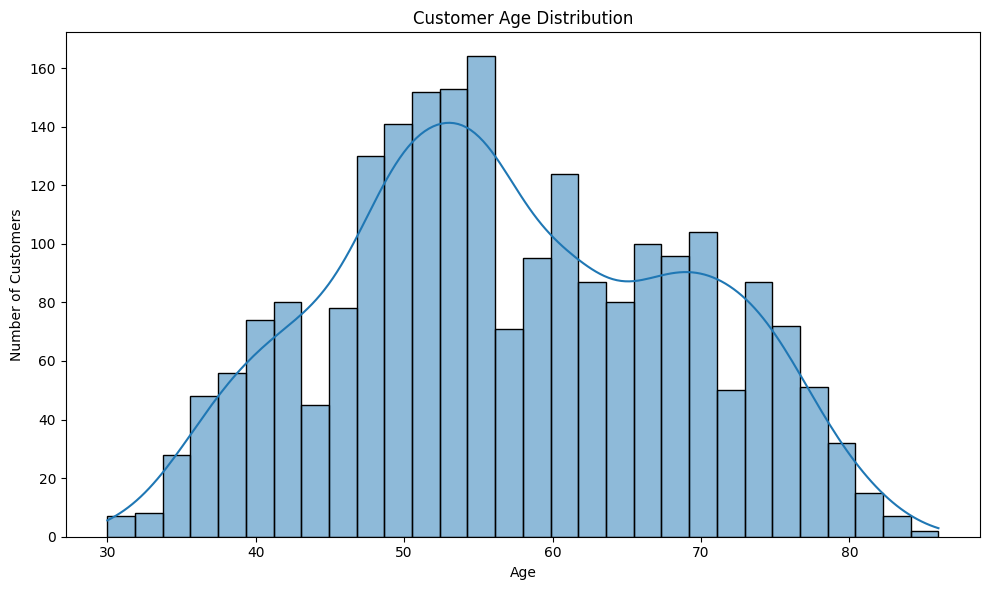

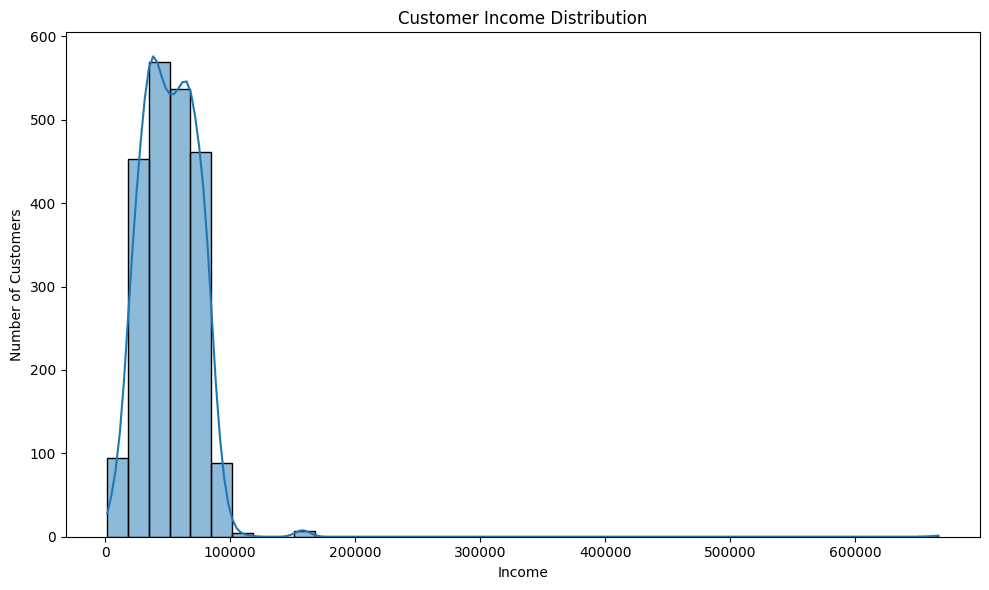

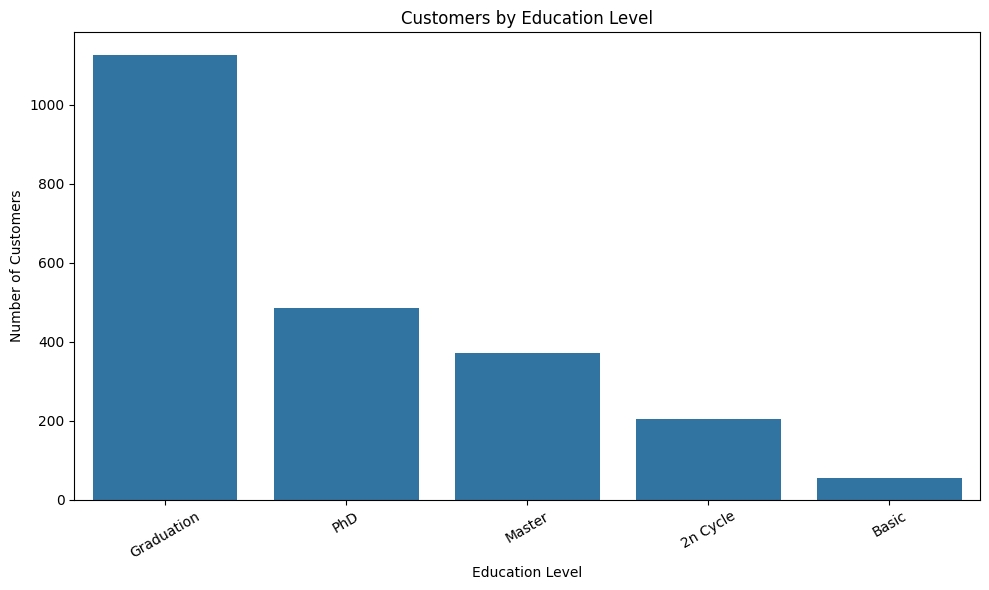

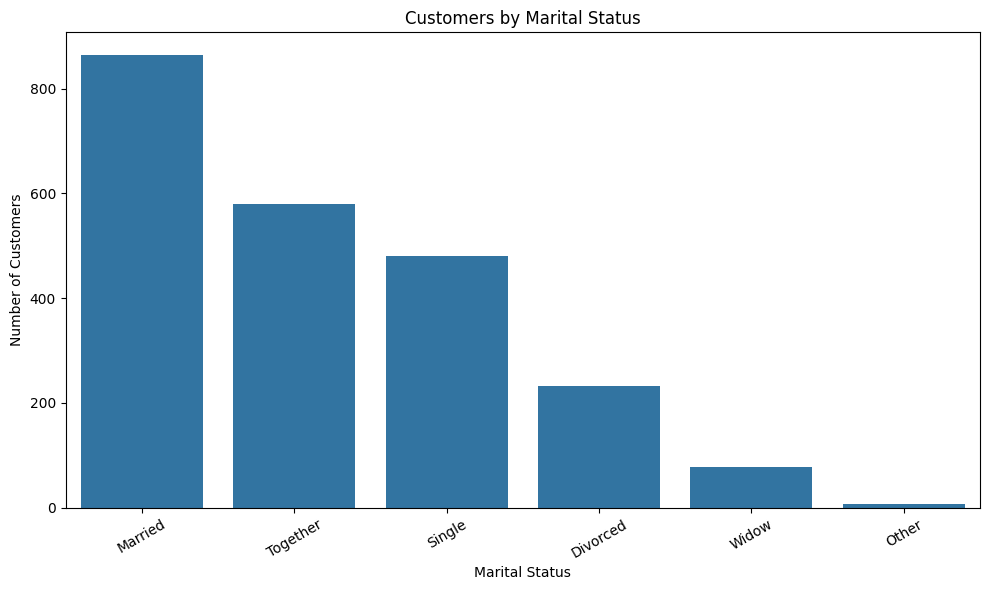

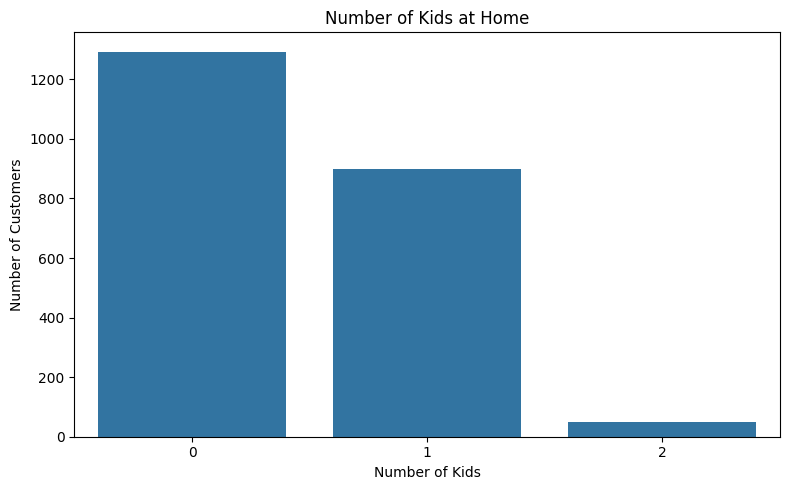

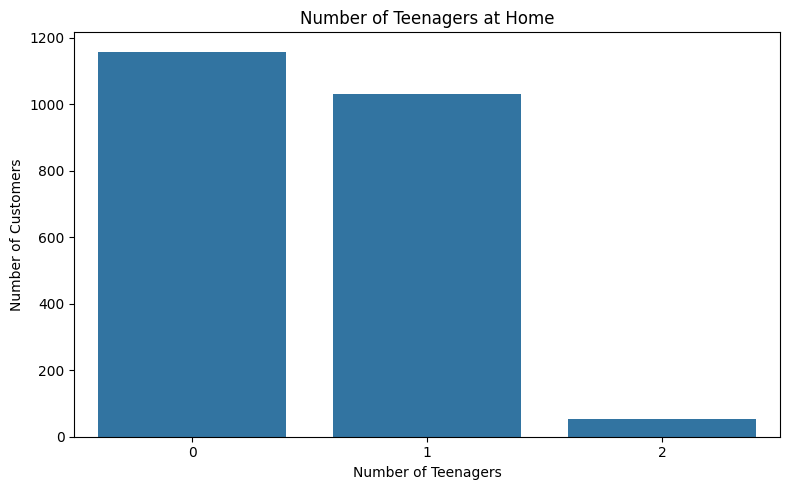

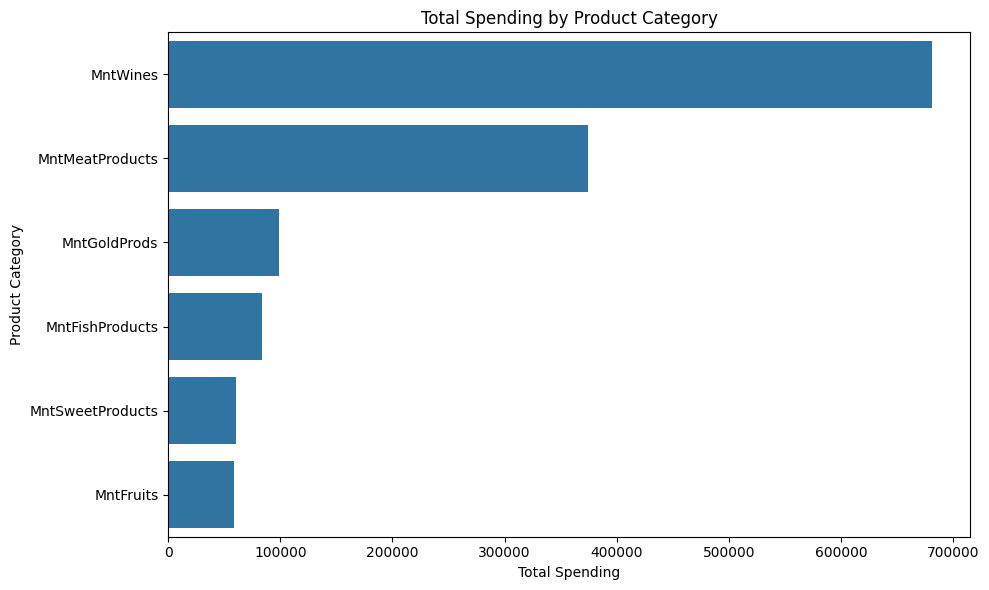

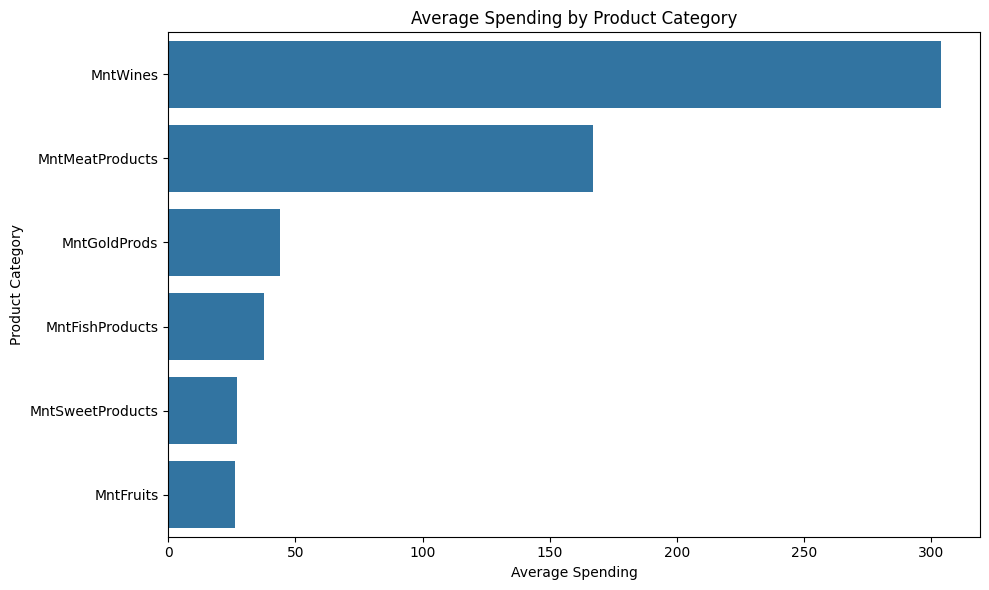

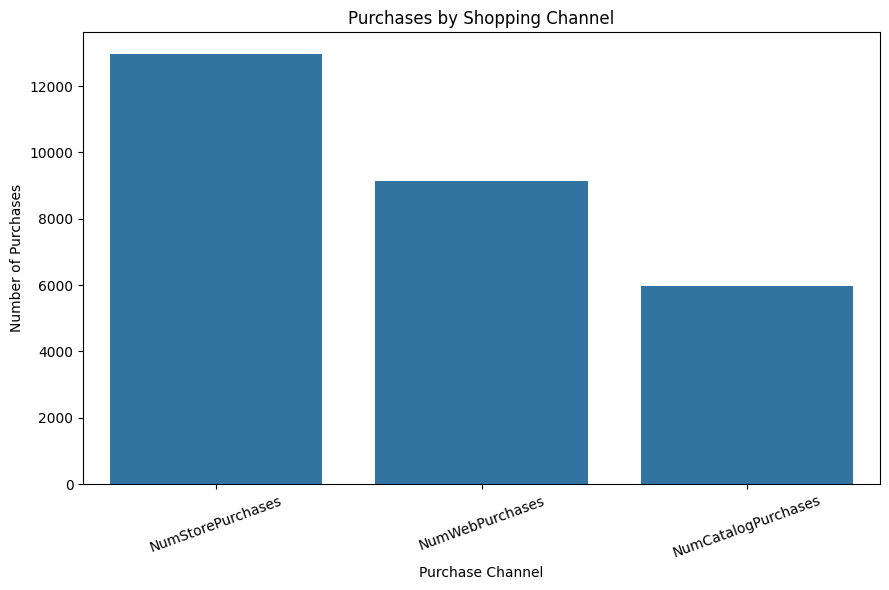

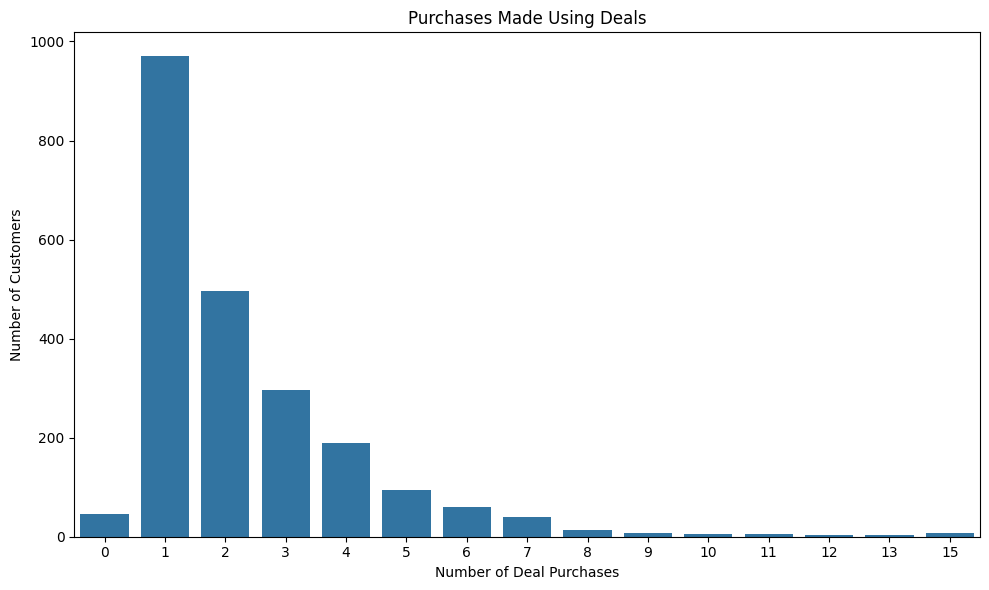

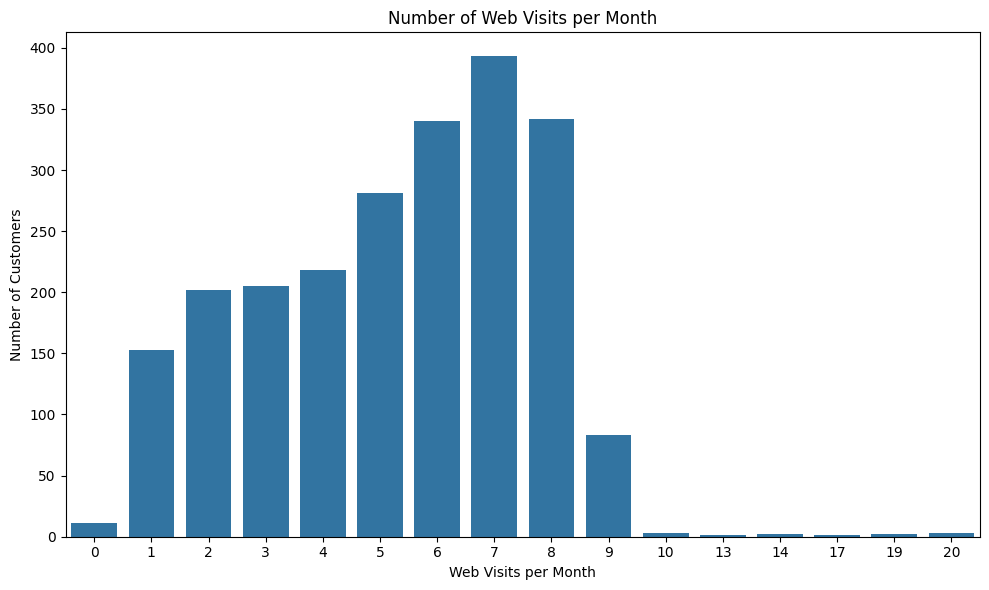

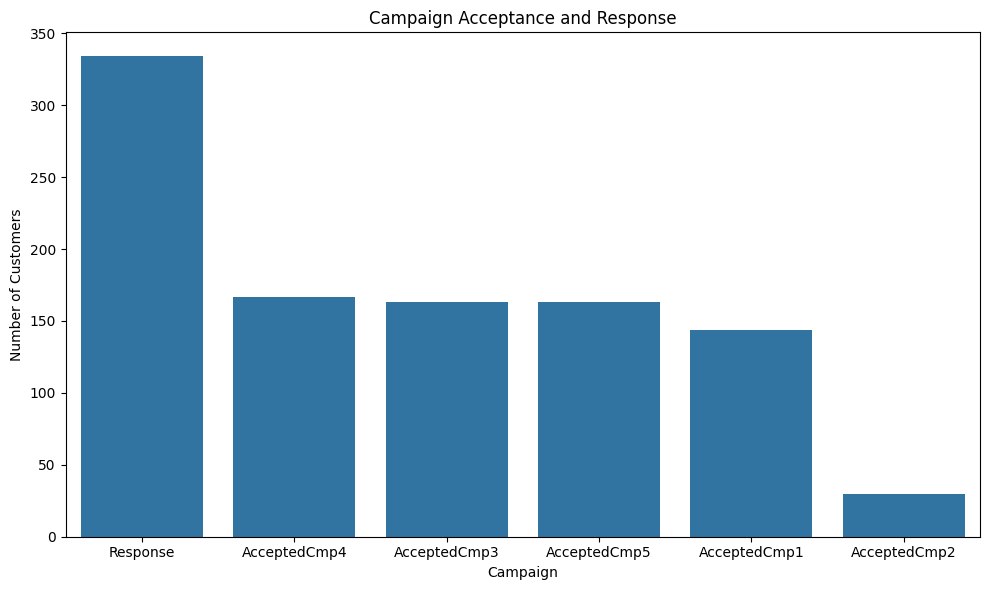

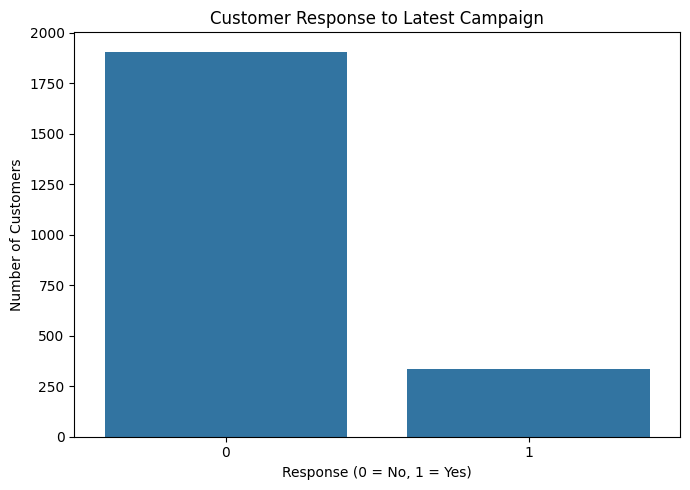

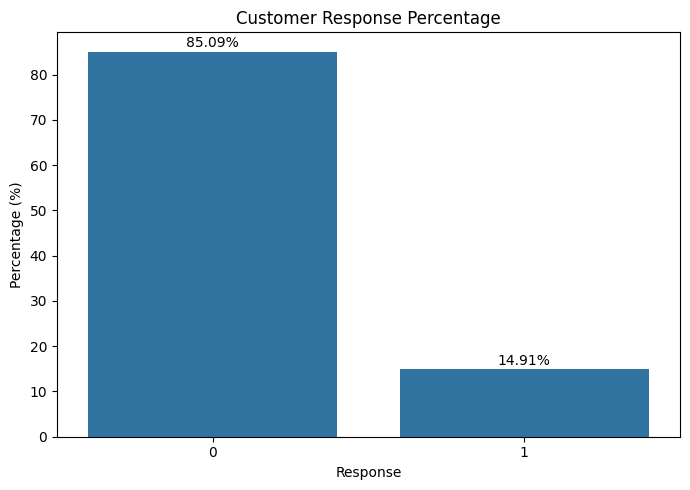

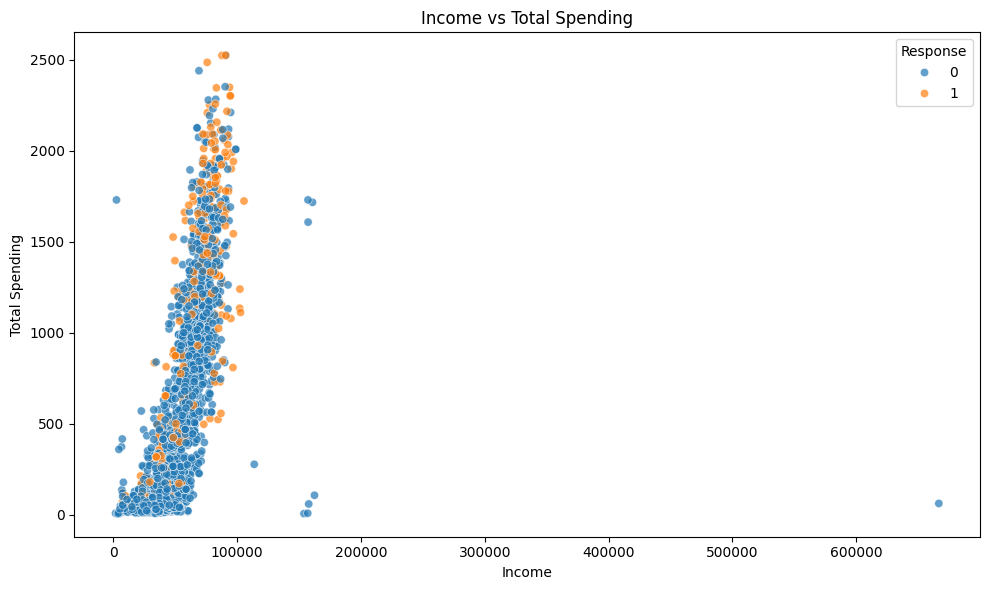

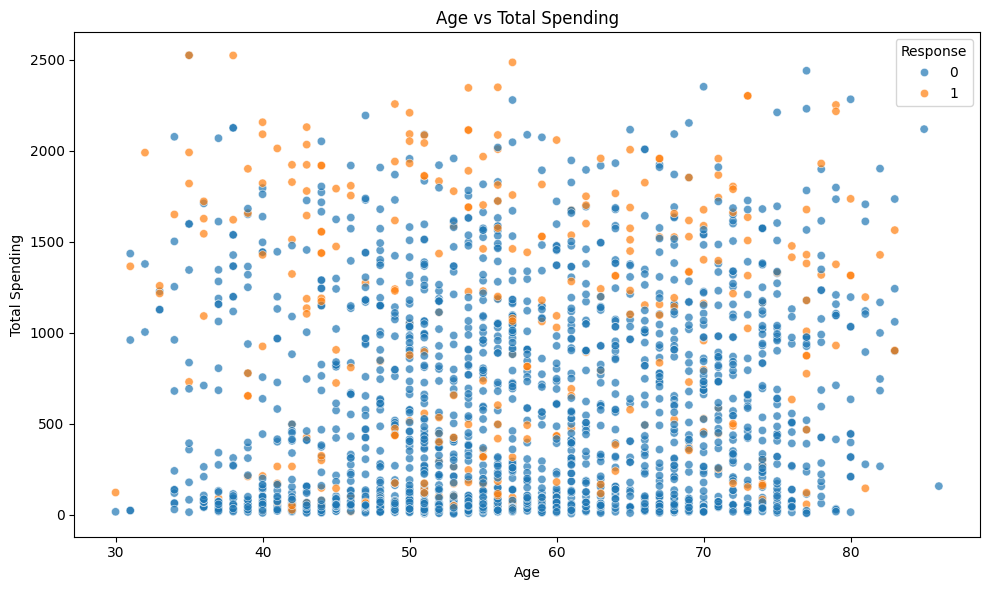

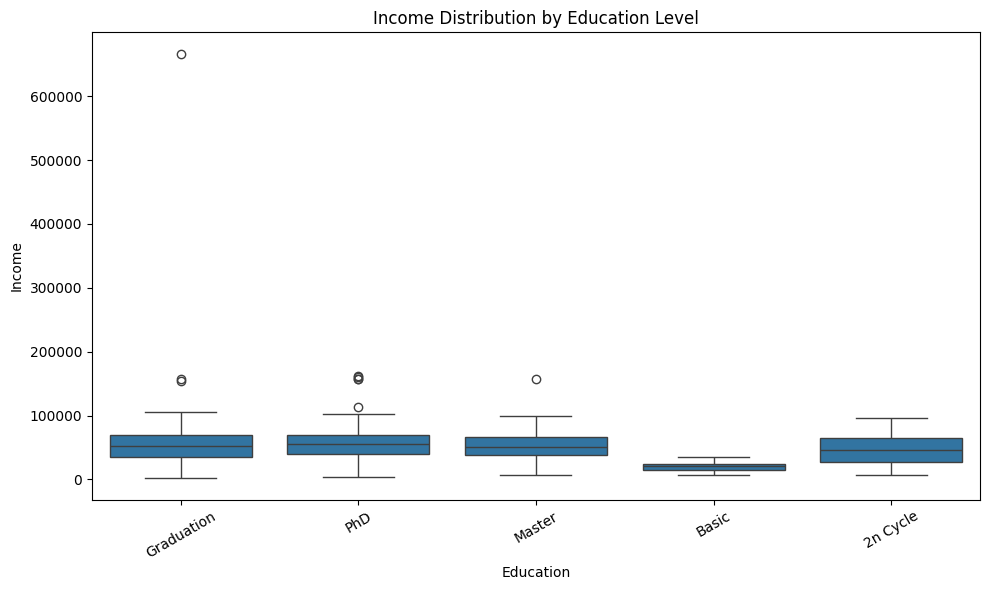

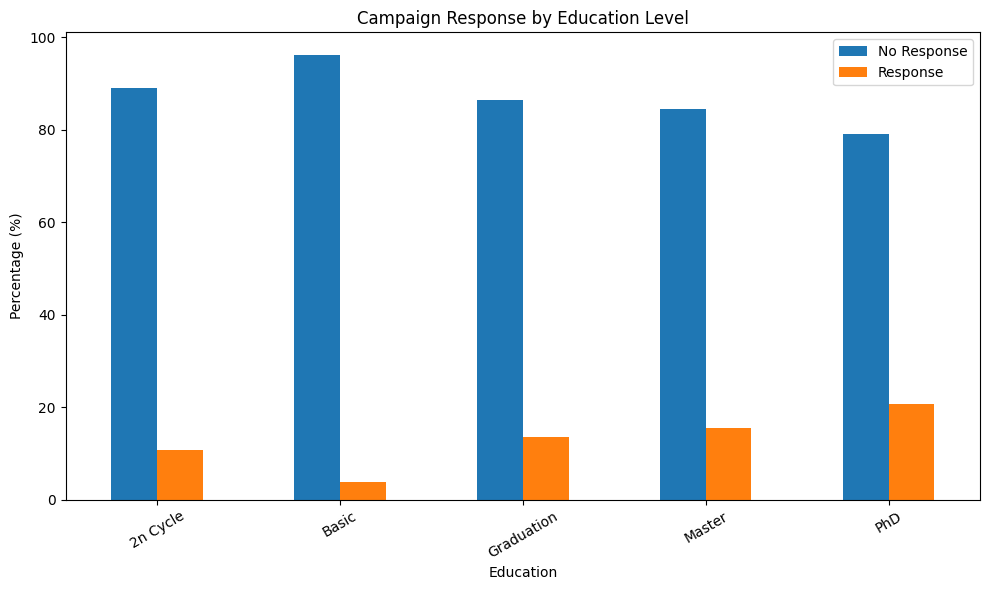

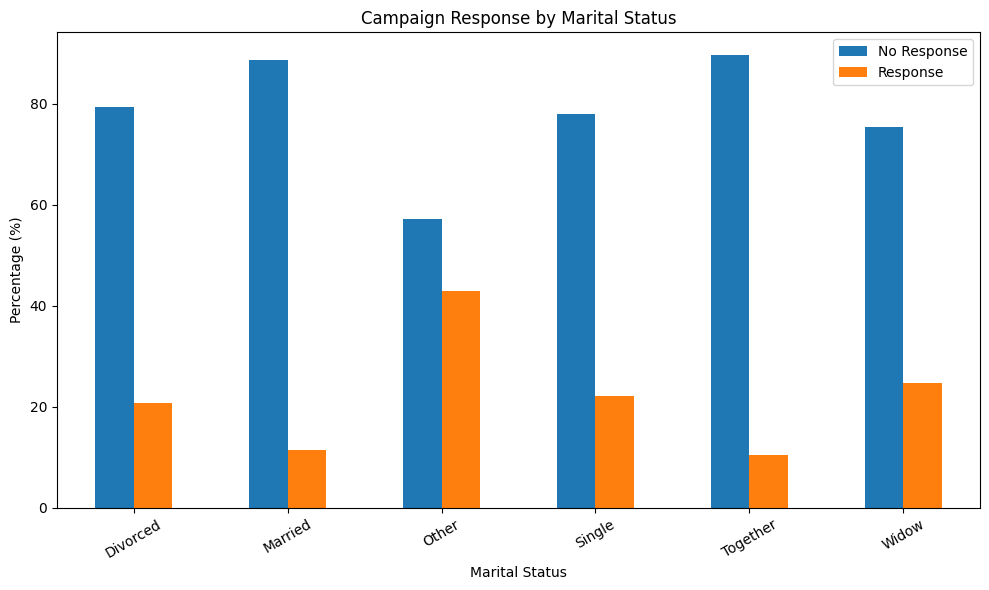

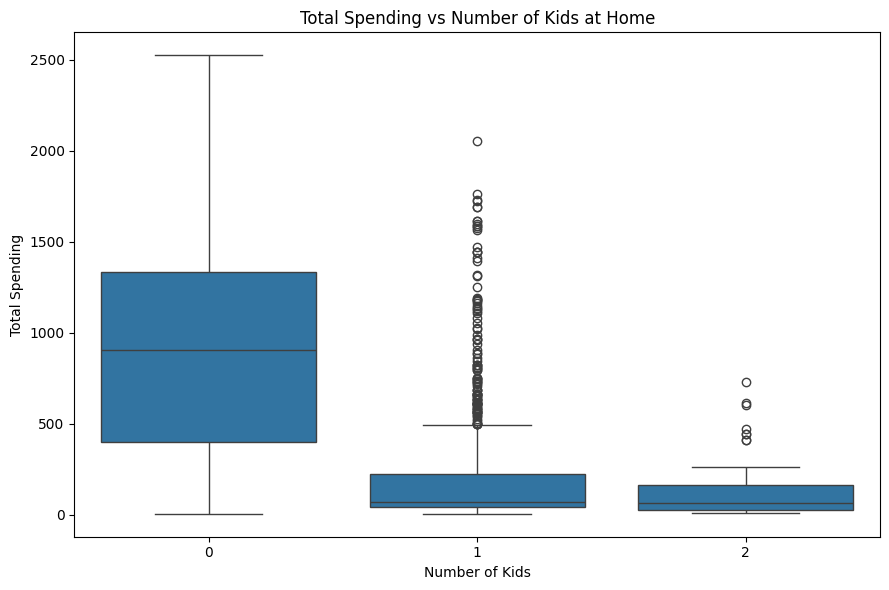

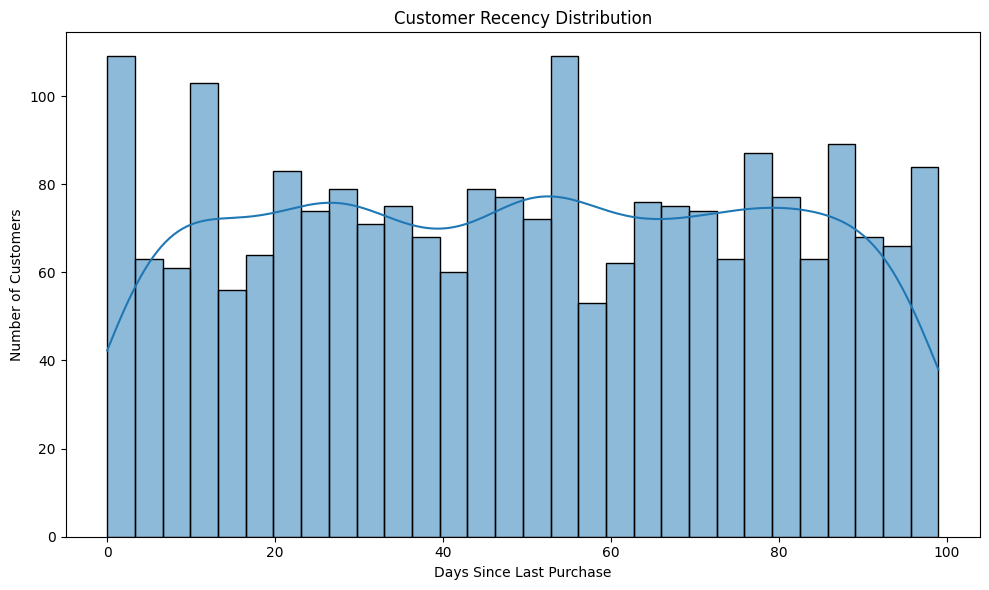

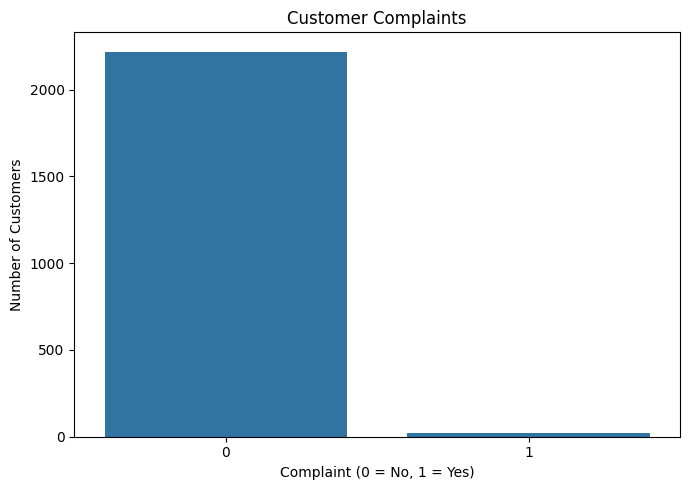

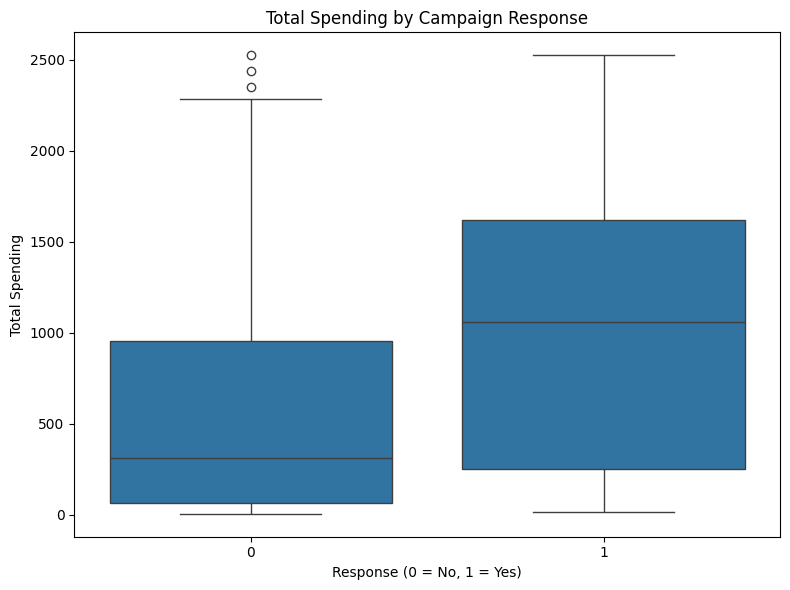

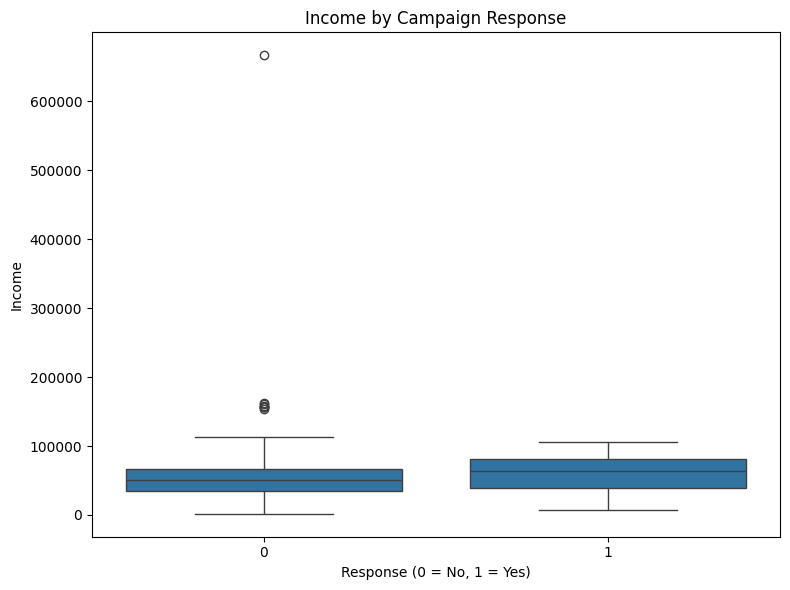

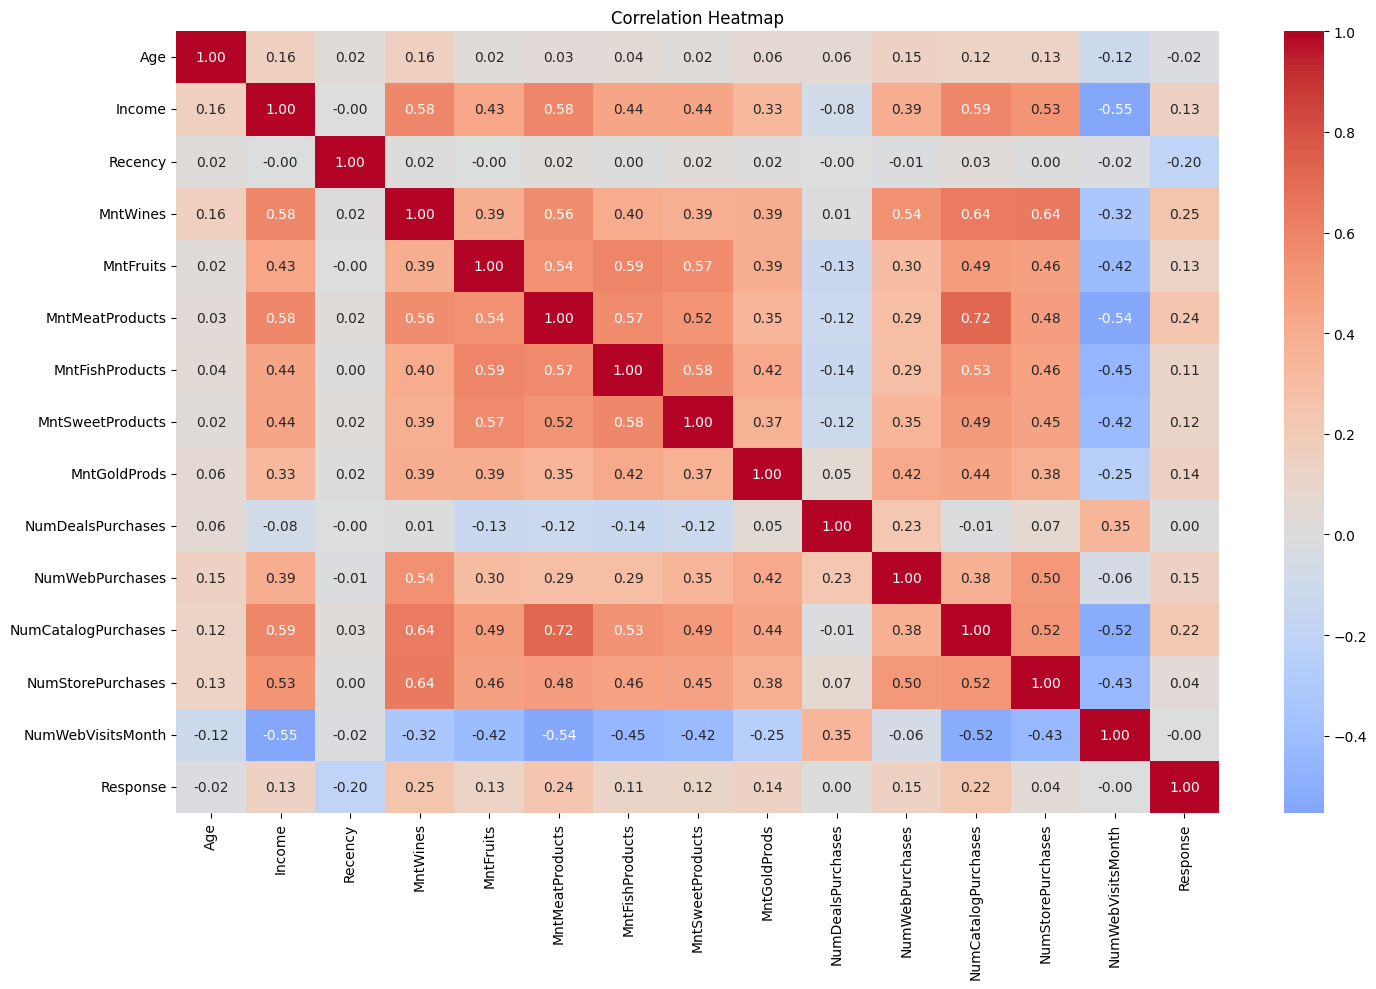

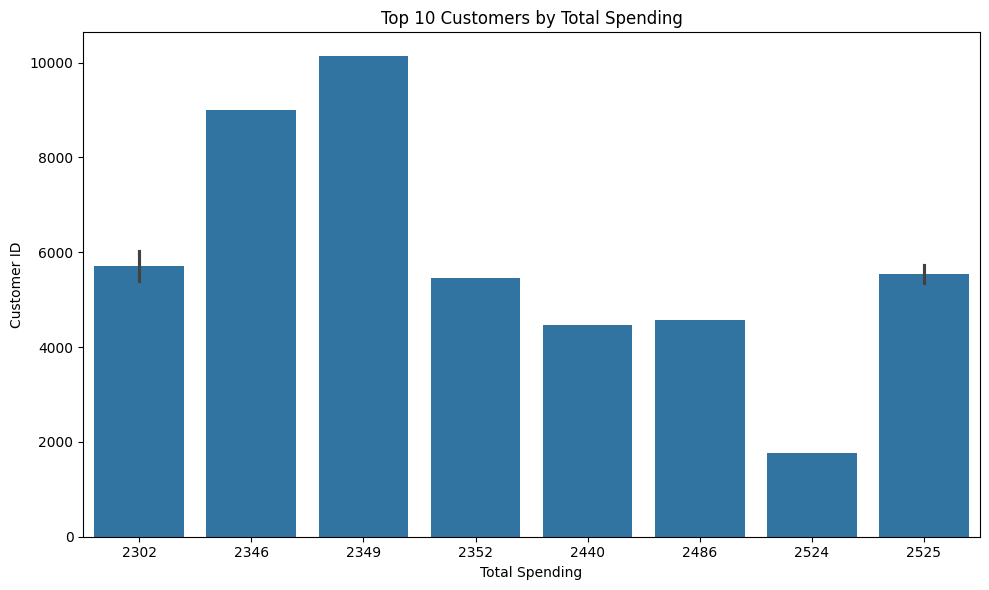



FINAL DATASET SUMMARY
Number of Customers: 2240
Number of Features: 31
Average Income: 52247.25
Average Total Spending: 605.8
Campaign Response Rate: 14.91 %
Most Common Education: Graduation
Highest Spending Category: MntWines
Most Used Purchase Channel: NumStorePurchases
Total Complaints: 21
EDA COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# CUSTOMER PERSONALITY / MARKETING CAMPAIGN DATASET
# COMPLETE GRAPHICAL EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = "/content/sample_data/marketing_campaign.csv"

df = pd.read_csv(file_path, sep="\t")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. BASIC INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

print("Duplicates:", df.duplicated().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()


# ============================================================
# 4. HANDLE DATE COLUMN
# ============================================================

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)


# ============================================================
# 5. HANDLE MARITAL STATUS
# ============================================================

df["Marital_Status"] = df["Marital_Status"].replace(
    ["YOLO", "Absurd", "Alone"],
    "Other"
)


# ============================================================
# 6. CREATE AGE
# ============================================================

current_year = 2026

df["Age"] = current_year - df["Year_Birth"]


# ============================================================
# 7. CREATE TOTAL SPENDING
# ============================================================

spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_columns].sum(axis=1)


# ============================================================
# IMPORTANT:
# CREATE df_age AFTER Total_Spending
# ============================================================

df_age = df[
    (df["Age"] >= 18) &
    (df["Age"] <= 100)
].copy()


# ============================================================
# 8. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df_age["Age"],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 9. INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Income"].dropna(),
    bins=40,
    kde=True
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 10. EDUCATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Education",
    order=df["Education"].value_counts().index
)

plt.title("Customers by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 11. MARITAL STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Marital_Status",
    order=df["Marital_Status"].value_counts().index
)

plt.title("Customers by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 12. NUMBER OF KIDS AT HOME
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Kidhome"
)

plt.title("Number of Kids at Home")
plt.xlabel("Number of Kids")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 13. NUMBER OF TEENAGERS AT HOME
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Teenhome"
)

plt.title("Number of Teenagers at Home")
plt.xlabel("Number of Teenagers")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 14. TOTAL SPENDING BY PRODUCT CATEGORY
# ============================================================

total_spending = (
    df[spending_columns]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=total_spending.values,
    y=total_spending.index
)

plt.title("Total Spending by Product Category")
plt.xlabel("Total Spending")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


# ============================================================
# 15. AVERAGE SPENDING BY PRODUCT CATEGORY
# ============================================================

average_spending = (
    df[spending_columns]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=average_spending.values,
    y=average_spending.index
)

plt.title("Average Spending by Product Category")
plt.xlabel("Average Spending")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


# ============================================================
# 16. PURCHASE CHANNEL ANALYSIS
# ============================================================

purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

purchase_totals = (
    df[purchase_columns]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=purchase_totals.index,
    y=purchase_totals.values
)

plt.title("Purchases by Shopping Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ============================================================
# 17. DEAL PURCHASES
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="NumDealsPurchases"
)

plt.title("Purchases Made Using Deals")
plt.xlabel("Number of Deal Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 18. WEB VISITS PER MONTH
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="NumWebVisitsMonth"
)

plt.title("Number of Web Visits per Month")
plt.xlabel("Web Visits per Month")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 19. CAMPAIGN ACCEPTANCE
# ============================================================

campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_totals = (
    df[campaign_columns]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=campaign_totals.index,
    y=campaign_totals.values
)

plt.title("Campaign Acceptance and Response")
plt.xlabel("Campaign")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 20. RESPONSE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Response"
)

plt.title("Customer Response to Latest Campaign")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 21. RESPONSE PERCENTAGE
# ============================================================

response_percentage = (
    df["Response"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=response_percentage.index.astype(str),
    y=response_percentage.values
)

plt.title("Customer Response Percentage")
plt.xlabel("Response")
plt.ylabel("Percentage (%)")

for i, value in enumerate(response_percentage.values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 22. INCOME VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Response",
    alpha=0.7
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()


# ============================================================
# 23. AGE VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_age,
    x="Age",
    y="Total_Spending",
    hue="Response",
    alpha=0.7
)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()


# ============================================================
# 24. EDUCATION VS INCOME
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Education",
    y="Income"
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 25. EDUCATION VS CAMPAIGN RESPONSE
# ============================================================

education_response = (
    pd.crosstab(
        df["Education"],
        df["Response"],
        normalize="index"
    )
    * 100
)

education_response.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Campaign Response by Education Level")
plt.xlabel("Education")
plt.ylabel("Percentage (%)")
plt.legend(["No Response", "Response"])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 26. MARITAL STATUS VS RESPONSE
# ============================================================

marital_response = (
    pd.crosstab(
        df["Marital_Status"],
        df["Response"],
        normalize="index"
    )
    * 100
)

marital_response.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Campaign Response by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage (%)")
plt.legend(["No Response", "Response"])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 27. KIDS AT HOME VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Kidhome",
    y="Total_Spending"
)

plt.title("Total Spending vs Number of Kids at Home")
plt.xlabel("Number of Kids")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()


# ============================================================
# 28. RECENCY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Recency",
    bins=30,
    kde=True
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 29. CUSTOMER COMPLAINTS
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Complain"
)

plt.title("Customer Complaints")
plt.xlabel("Complaint (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 30. RESPONSE VS TOTAL SPENDING
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Response",
    y="Total_Spending"
)

plt.title("Total Spending by Campaign Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()


# ============================================================
# 31. RESPONSE VS INCOME
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Response",
    y="Income"
)

plt.title("Income by Campaign Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Income")
plt.tight_layout()
plt.show()


# ============================================================
# 32. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Age",
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Response"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# 33. TOP 10 CUSTOMERS BY SPENDING
# ============================================================

top_customers = df.nlargest(
    10,
    "Total_Spending"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    x="Total_Spending",
    y="ID"
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()


# ============================================================
# 34. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print("Number of Customers:", len(df))

print("Number of Features:", len(df.columns))

print(
    "Average Income:",
    round(df["Income"].mean(), 2)
)

print(
    "Average Total Spending:",
    round(df["Total_Spending"].mean(), 2)
)

print(
    "Campaign Response Rate:",
    round(df["Response"].mean() * 100, 2),
    "%"
)

print(
    "Most Common Education:",
    df["Education"].mode()[0]
)

print(
    "Highest Spending Category:",
    total_spending.index[0]
)

print(
    "Most Used Purchase Channel:",
    purchase_totals.index[0]
)

print(
    "Total Complaints:",
    df["Complain"].sum()
)

print("=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)